In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = ""

import numpy as np
import pandas as pd
import anndata as ad
import scanpy as sc
import colorcet as cc
import matplotlib.pyplot as plt
from rich import print

In [5]:
sc.settings._vector_friendly = True
# Set SVG font type to 'none' to keep text as text in SVG files
plt.rcParams["svg.fonttype"] = "none"

In [6]:
DATA_FOLDER: str = "/home/nathanl/Data/cosmx_cortex/"
DATA_FILE: str = "cosmx_cortex_hvg5000.h5ad"

FIGURE_DIR: str = "/home/nathanl/scviva_paper/cosmx_brain/figures/duplicate/"

import os

os.makedirs(FIGURE_DIR, exist_ok=True)

# Duplication ("displaced cell") experiment - CosMx human frontal cortex


In [7]:
# ---- experiment configuration (switch these to run an alternate contrast) ----
target_cell_type = "astro.2"
target_region = "Vessel / Peri-Vascular"  # where the duplicates GO
source_regions = ["Upper Cortical Layers (L2/3)"]  # where they COME FROM

run_tag = "astro.2_upper_vessel"

# ---- obs keys, matching brain/cosmx_brain/params.py ----
LABEL: str = "cell_type"
CELL_TYPE: str = "cell_type"
NICHE: str = "region"
BATCH: str = "batch"
SAMPLE: str = "batch"
COORDS: str = "spatial"

n_sampled_per_batch = 1500

#
# DEFAULT None, i.e. OFF, for exact parity with the merfish and CRC notebooks
REGION_PURITY_MIN = None

adata = sc.read_h5ad(DATA_FOLDER + DATA_FILE)
print(adata)

AnnData object with n_obs × n_vars = 188686 × 5000
    obs: 'cell_ID', 'nCount_RNA', 'nFeature_RNA', 'nCount_negprobes', 'nFeature_negprobes', 'nCount_falsecode', 
'nFeature_falsecode', 'fov', 'Area', 'AspectRatio', 'Width', 'Height', 'Mean.Histone', 'Max.Histone', 'Mean.G', 
'Max.G', 'Mean.rRNA', 'Max.rRNA', 'Mean.GFAP', 'Max.GFAP', 'Mean.DAPI', 'Max.DAPI', 'cell_id', 'assay_type', 
'dualfiles', 'Run_name', 'ISH.concentration', 'Dash', 'tissue', 'slide_ID', 'Run_Tissue_name', 'Panel', 
'assay_type.1', 'version', 'Area.um2', 'CenterX_local_px', 'CenterY_local_px', 'CenterX_global_px', 
'CenterY_global_px', 'propNegative', 'complexity', 'errorCtEstimate', 'percOfDataFromError', 'qcFlagsRNACounts', 
'qcFlagsCellCounts', 'qcFlagsCellPropNeg', 'qcFlagsCellComplex', 'qcFlagsCellArea', 'qcCellsFlagged', 
'median_negprobes', 'negprobes_quantile_0.9', 'median_RNA', 'RNA_quantile_0.9', 'nCell', 'nCount', 'nCountPerCell',
'nFeaturePerCell', 'propNegativeCellAvg', 'complexityCellAvg', 'errorCtPerCellEstimate', 
'percOfDataFromErrorPerCell', 'qcFlagsFOV', 'RefinedClusts_Final', 'prob', 
'RNA_spatialClusteringNeighbours_astro.1', 'RNA_spatialClusteringNeighbours_astro.2', 
'RNA_spatialClusteringNeighbours_endothelial', 'RNA_spatialClusteringNeighbours_Inh.1', 
'RNA_spatialClusteringNeighbours_Inh.2', 'RNA_spatialClusteringNeighbours_Inh.3', 
'RNA_spatialClusteringNeighbours_L2_3', 'RNA_spatialClusteringNeighbours_L4', 'RNA_spatialClusteringNeighbours_L6',
'RNA_spatialClusteringNeighbours_microglia.1', 'RNA_spatialClusteringNeighbours_microglia.2', 
'RNA_spatialClusteringNeighbours_oligodendrocyte', 'RNA_spatialClusteringNeighbours_OPC', 
'RNA_spatialClusteringNeighbours_unknown', 'spatialClusteringAssignments', 'batch', 'cell_type', 
'n_genes_by_counts', 'total_counts', '_scvi_batch', '_scvi_labels', 'index', 'niche_cluster', 'region'
    var: 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'mt', 'highly_variable', 
'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'cell_type_to_int', 'hvg', 'log1p', 'negative_probe_names', 
'niche_cluster_colors', 'region_colors'
    obsm: 'X_banksy_02_harmony', 'banksy_pc_20_lambda_0.2', 'banksy_pc_20_nonspatial', 'negative_probes', 
'neighborhood_composition', 'niche_distances', 'niche_indexes', 'qz1_m_niche_ct', 'simvi25_all_mae_50', 
'simvi25_both_mae_50', 'simvi25_interact_mae_50', 'simvi25_intrinsic_mae_50', 'spatial'
    layers: 'counts'

In [16]:
# feasibility: how many target-cell-type cells live in the source vs target regions?
ct_by_region = pd.crosstab(adata.obs[CELL_TYPE], adata.obs[NICHE])
display(ct_by_region)

n_target = ct_by_region.loc[target_cell_type, target_region]
n_source = int(ct_by_region.loc[target_cell_type, source_regions].sum())
print(f"{target_cell_type}: n_target({target_region})={n_target}, n_source({source_regions})={n_source}")
print(f"-> will duplicate {min(n_sampled_per_batch, n_target, n_source)} cells")

region,Deep Cortical Layers (L4/L6),Upper Cortical Layers (L2/3),Vessel / Peri-Vascular,White Matter
cell_type,,,,
Inh.1,1277,1231,138,69
Inh.2,287,350,125,151
Inh.3,2061,2805,992,412
L2_3,1941,11746,725,37
L4,7375,851,468,107
L6,4882,588,476,1663
OPC,1388,1184,531,2644
astro.1,235,22,1487,10687
astro.2,3958,3844,1664,265


astro.2: n_target(Vessel / Peri-Vascular)=1664, n_source(['Upper Cortical Layers (L2/3)'])=3844

-> will duplicate 1500 cells

In [17]:
# Filter out cells with very low counts to prevent NaN during training
counts = adata.layers["counts"]
cell_counts = counts.toarray().sum(axis=1) if hasattr(counts, "toarray") else counts.sum(axis=1)

n_cells_before = adata.n_obs
min_counts = 10
adata = adata[cell_counts >= min_counts].copy()
print(f"Filtered {n_cells_before - adata.n_obs} cells with < {min_counts} counts")
print(adata)

Filtered 0 cells with < 10 counts

AnnData object with n_obs × n_vars = 188686 × 5000
    obs: 'cell_ID', 'nCount_RNA', 'nFeature_RNA', 'nCount_negprobes', 'nFeature_negprobes', 'nCount_falsecode', 
'nFeature_falsecode', 'fov', 'Area', 'AspectRatio', 'Width', 'Height', 'Mean.Histone', 'Max.Histone', 'Mean.G', 
'Max.G', 'Mean.rRNA', 'Max.rRNA', 'Mean.GFAP', 'Max.GFAP', 'Mean.DAPI', 'Max.DAPI', 'cell_id', 'assay_type', 
'dualfiles', 'Run_name', 'ISH.concentration', 'Dash', 'tissue', 'slide_ID', 'Run_Tissue_name', 'Panel', 
'assay_type.1', 'version', 'Area.um2', 'CenterX_local_px', 'CenterY_local_px', 'CenterX_global_px', 
'CenterY_global_px', 'propNegative', 'complexity', 'errorCtEstimate', 'percOfDataFromError', 'qcFlagsRNACounts', 
'qcFlagsCellCounts', 'qcFlagsCellPropNeg', 'qcFlagsCellComplex', 'qcFlagsCellArea', 'qcCellsFlagged', 
'median_negprobes', 'negprobes_quantile_0.9', 'median_RNA', 'RNA_quantile_0.9', 'nCell', 'nCount', 'nCountPerCell',
'nFeaturePerCell', 'propNegativeCellAvg', 'complexityCellAvg', 'errorCtPerCellEstimate', 
'percOfDataFromErrorPerCell', 'qcFlagsFOV', 'RefinedClusts_Final', 'prob', 
'RNA_spatialClusteringNeighbours_astro.1', 'RNA_spatialClusteringNeighbours_astro.2', 
'RNA_spatialClusteringNeighbours_endothelial', 'RNA_spatialClusteringNeighbours_Inh.1', 
'RNA_spatialClusteringNeighbours_Inh.2', 'RNA_spatialClusteringNeighbours_Inh.3', 
'RNA_spatialClusteringNeighbours_L2_3', 'RNA_spatialClusteringNeighbours_L4', 'RNA_spatialClusteringNeighbours_L6',
'RNA_spatialClusteringNeighbours_microglia.1', 'RNA_spatialClusteringNeighbours_microglia.2', 
'RNA_spatialClusteringNeighbours_oligodendrocyte', 'RNA_spatialClusteringNeighbours_OPC', 
'RNA_spatialClusteringNeighbours_unknown', 'spatialClusteringAssignments', 'batch', 'cell_type', 
'n_genes_by_counts', 'total_counts', '_scvi_batch', '_scvi_labels', 'index', 'niche_cluster', 'region'
    var: 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'mt', 'highly_variable', 
'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'cell_type_to_int', 'hvg', 'log1p', 'negative_probe_names', 
'niche_cluster_colors', 'region_colors'
    obsm: 'X_banksy_02_harmony', 'banksy_pc_20_lambda_0.2', 'banksy_pc_20_nonspatial', 'negative_probes', 
'neighborhood_composition', 'niche_distances', 'niche_indexes', 'qz1_m_niche_ct', 'simvi25_all_mae_50', 
'simvi25_both_mae_50', 'simvi25_interact_mae_50', 'simvi25_intrinsic_mae_50', 'spatial'
    layers: 'counts'

## Build the duplicated object

Note this dataset is a **single slide** (`batch == 'S3'`), so the per-batch loop below runs once -
kept as a loop to stay faithful to the CRC/merfish version of the analysis.

In [18]:
# spatial purity: fraction of each cell's 20 nearest spatial neighbours in the same region
if REGION_PURITY_MIN is not None:
    from sklearn.neighbors import NearestNeighbors

    _S = np.asarray(adata.obsm[COORDS], dtype=float)
    _reg = adata.obs[NICHE].to_numpy()
    _, _idx = NearestNeighbors(n_neighbors=21).fit(_S).kneighbors(_S)
    adata.obs["region_purity"] = (_reg[_idx[:, 1:]] == _reg[:, None]).mean(1)
    print(adata.obs.groupby(NICHE, observed=True)["region_purity"].mean().round(3))

adata.obs["replacement_status"] = "untouched"  # default

all_duplicated = []
all_source_original = []
all_replaced_ids = []

for batch in adata.obs[BATCH].unique():
    print(f"\nProcessing batch: {batch}")
    batch_mask = adata.obs[BATCH] == batch

    target_mask = (adata.obs[LABEL] == target_cell_type) & (adata.obs[NICHE] == target_region) & batch_mask
    source_mask = (adata.obs[LABEL] == target_cell_type) & (adata.obs[NICHE].isin(source_regions)) & batch_mask

    # drop cells embedded in another region, so every duplicate really does change environment
    if REGION_PURITY_MIN is not None:
        pure = adata.obs["region_purity"] >= REGION_PURITY_MIN
        print(f"  purity filter: target {target_mask.sum()} -> {(target_mask & pure).sum()}, "
              f"source {source_mask.sum()} -> {(source_mask & pure).sum()}")
        target_mask = target_mask & pure
        source_mask = source_mask & pure

    target_cells = adata[target_mask].copy()
    source_cells = adata[source_mask].copy()

    n_target, n_source = target_cells.shape[0], source_cells.shape[0]
    print(f"  n_target={n_target}, n_source={n_source}")

    if n_target < 1 or n_source < 1:
        print("  Skipping batch (not enough target/source cells)")
        continue

    n_sampled = min(n_sampled_per_batch, n_target, n_source)
    print(f"  Sampling {n_sampled} cells for duplication")

    target_ids = np.random.choice(target_cells.obs_names, n_sampled, replace=False)
    target_subset = target_cells[target_ids].copy()

    sampled_ids = np.random.choice(source_cells.obs_names, n_sampled, replace=False)
    duplicated = source_cells[sampled_ids].copy()
    source_original = duplicated.copy()

    # expression is intentionally NOT touched - only the spatial position / niche moves
    duplicated.obsm[COORDS] = target_subset.obsm[COORDS].copy()

    duplicated.obs[NICHE] = target_region
    duplicated.obs[BATCH] = batch
    duplicated.obs[SAMPLE] = batch
    duplicated.obs_names = [f"{idx}_replaced" for idx in sampled_ids]
    duplicated.obs["replacement_status"] = "duplicated"

    source_original.obs["replacement_status"] = "original"

    target_unused_ids = list(set(target_cells.obs_names) - set(target_ids))
    adata.obs.loc[target_unused_ids, "replacement_status"] = "untouched"

    all_replaced_ids.extend(target_ids)
    all_duplicated.append(duplicated)
    all_source_original.append(source_original)

# drop the target cells whose coordinates were taken over
adata = adata[~adata.obs_names.isin(all_replaced_ids)].copy()

# drop the source cells that were sampled (they come back via source_original)
from functools import reduce

sampled_source_ids = reduce(
    lambda x, y: x.union(y), [a.obs_names.str.replace("_replaced", "", regex=False) for a in all_duplicated]
)
adata = adata[~adata.obs_names.isin(sampled_source_ids)].copy()

adata_displaced = ad.concat([adata] + all_source_original + all_duplicated, axis=0)
print(f"\nFinal shape after displacement: {adata_displaced.shape}")
print(adata_displaced.obs["replacement_status"].value_counts())

Processing batch: S3

n_target=1664, n_source=3844

Sampling 1500 cells for duplication

Final shape after displacement: (188686, 5000)

replacement_status
untouched     185686
original        1500
duplicated      1500
Name: count, dtype: int64

In [19]:
# sanity check: duplicated expression must be identical to its source (MSE ~ 0)
from sklearn.metrics import mean_squared_error

sub = adata_displaced[adata_displaced.obs[LABEL] == target_cell_type].copy()
dup = sub[sub.obs["replacement_status"] == "duplicated"]
orig = sub[[idx.replace("_replaced", "") for idx in dup.obs_names]]

mse = mean_squared_error(
    orig.X.toarray() if hasattr(orig.X, "toarray") else orig.X,
    dup.X.toarray() if hasattr(dup.X, "toarray") else dup.X,
)
print(f"MSE between duplicated and original expression profiles: {mse:.6e}  (should be 0)")

MSE between duplicated and original expression profiles: 0.000000e+00  (should be 0)

/home/nathanl/miniforge3/envs/scvi/lib/python3.12/site-packages/anndata/_core/anndata.py:1138: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/nathanl/miniforge3/envs/scvi/lib/python3.12/site-packages/anndata/_core/anndata.py:1138: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/nathanl/miniforge3/envs/scvi/lib/python3.12/site-packages/anndata/_core/anndata.py:1138: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/nathanl/miniforge3/envs/scvi/lib/python3.12/site-packages/anndata/_core/anndata.py:1138: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


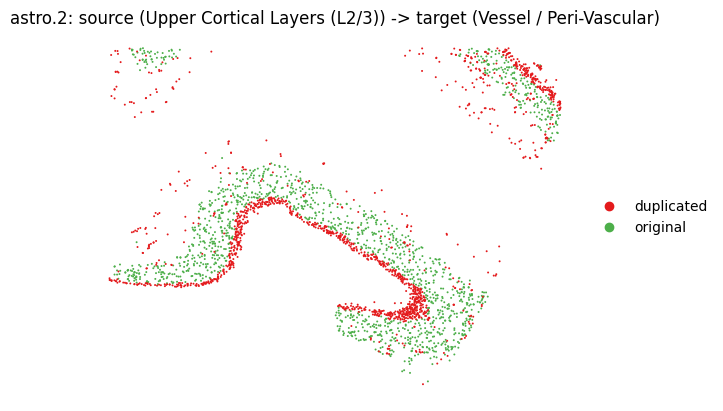

In [20]:
# where the duplicates landed vs where they came from
plot_mask = (adata_displaced.obs[LABEL] == target_cell_type) & (
    adata_displaced.obs["replacement_status"].isin(["original", "duplicated"])
)

sc.pl.embedding(
    adata_displaced[plot_mask],
    basis="spatial",
    color="replacement_status",
    size=8,
    groups=["duplicated", "original"],
    palette=["#e41a1c", "#4daf4a"],
    title=f"{target_cell_type}: source ({source_regions[0]}) -> target ({target_region})",
    frameon=False,
    show=False,
)
plt.savefig(f"{FIGURE_DIR}cosmx_{run_tag}_replacement.png", bbox_inches="tight", dpi=300)
plt.savefig(f"{FIGURE_DIR}cosmx_{run_tag}_replacement.svg", bbox_inches="tight", dpi=300)

In [21]:
# The duplicates carry stale spatial embeddings copied from their SOURCE position.
# Drop them: they must be recomputed against the new coordinates (see next cell), and
# leaving them in place would silently produce a backwards result if that step is skipped.
STALE_SPATIAL_KEYS = [k for k in list(adata_displaced.obsm) if k.startswith(("banksy", "X_banksy", "simvi"))]
for k in STALE_SPATIAL_KEYS:
    del adata_displaced.obsm[k]
print("dropped stale spatial embeddings:", STALE_SPATIAL_KEYS)

out_path = f"{DATA_FOLDER}cosmx_cortex_{run_tag}_replaced.h5ad"
adata_displaced.write_h5ad(out_path)
print("wrote", out_path)

dropped stale spatial embeddings:
[
    'X_banksy_02_harmony',
    'banksy_pc_20_lambda_0.2',
    'banksy_pc_20_nonspatial',
    'simvi25_all_mae_50',
    'simvi25_both_mae_50',
    'simvi25_interact_mae_50',
    'simvi25_intrinsic_mae_50'
]

wrote /home/nathanl/Data/cosmx_cortex/cosmx_cortex_astro.2_upper_vessel_replaced.h5ad

## Recompute all embeddings on the duplicated object

```bash
# 1. SimVI + BANKSY - recomputes spatial embeddings against the NEW coordinates
cd /home/nathanl/scviva_paper/baselines
./run_benchmark.sh cosmx_cortex_microglia.2_wm_vessel_replaced 1     # <gpu id>

# 2. scANVI + nicheVI - picks up the file now containing BANKSY/SimVI, and adds
#    X_scanvi, the nicheVI latent
cd /home/nathanl/scviva_paper
CUDA_VISIBLE_DEVICES=1 DUP_CELL_TYPE=microglia.2_wm_vessel \
    /home/nathanl/miniforge3/envs/scvi/bin/python runner.py cosmx_brain/duplicate
```

# Results after training on the duplicated object

In [8]:
NICHEVI_KEY = "s10_scanvi_lr0.0005_poisson_X_nicheVI"

CHECKPOINT_DIR = "/home/nathanl/scviva_paper/cosmx_brain/checkpoints/"
trained_path = f"{CHECKPOINT_DIR}cosmx_cortex_{run_tag}_replaced/cosmx_cortex_{run_tag}_replaced_nicheVI.h5ad"

adata_displaced = ad.read_h5ad(trained_path)
adata_target = adata_displaced[adata_displaced.obs[LABEL] == target_cell_type].copy()
print(adata_target)
print(adata_target.obs["replacement_status"].value_counts())

AnnData object with n_obs × n_vars = 9731 × 5000
    obs: 'cell_ID', 'nCount_RNA', 'nFeature_RNA', 'nCount_negprobes', 'nFeature_negprobes', 'nCount_falsecode', 
'nFeature_falsecode', 'fov', 'Area', 'AspectRatio', 'Width', 'Height', 'Mean.Histone', 'Max.Histone', 'Mean.G', 
'Max.G', 'Mean.rRNA', 'Max.rRNA', 'Mean.GFAP', 'Max.GFAP', 'Mean.DAPI', 'Max.DAPI', 'cell_id', 'assay_type', 
'dualfiles', 'Run_name', 'ISH.concentration', 'Dash', 'tissue', 'slide_ID', 'Run_Tissue_name', 'Panel', 
'assay_type.1', 'version', 'Area.um2', 'CenterX_local_px', 'CenterY_local_px', 'CenterX_global_px', 
'CenterY_global_px', 'propNegative', 'complexity', 'errorCtEstimate', 'percOfDataFromError', 'qcFlagsRNACounts', 
'qcFlagsCellCounts', 'qcFlagsCellPropNeg', 'qcFlagsCellComplex', 'qcFlagsCellArea', 'qcCellsFlagged', 
'median_negprobes', 'negprobes_quantile_0.9', 'median_RNA', 'RNA_quantile_0.9', 'nCell', 'nCount', 'nCountPerCell',
'nFeaturePerCell', 'propNegativeCellAvg', 'complexityCellAvg', 'errorCtPerCellEstimate', 
'percOfDataFromErrorPerCell', 'qcFlagsFOV', 'RefinedClusts_Final', 'prob', 
'RNA_spatialClusteringNeighbours_astro.1', 'RNA_spatialClusteringNeighbours_astro.2', 
'RNA_spatialClusteringNeighbours_endothelial', 'RNA_spatialClusteringNeighbours_Inh.1', 
'RNA_spatialClusteringNeighbours_Inh.2', 'RNA_spatialClusteringNeighbours_Inh.3', 
'RNA_spatialClusteringNeighbours_L2_3', 'RNA_spatialClusteringNeighbours_L4', 'RNA_spatialClusteringNeighbours_L6',
'RNA_spatialClusteringNeighbours_microglia.1', 'RNA_spatialClusteringNeighbours_microglia.2', 
'RNA_spatialClusteringNeighbours_oligodendrocyte', 'RNA_spatialClusteringNeighbours_OPC', 
'RNA_spatialClusteringNeighbours_unknown', 'spatialClusteringAssignments', 'batch', 'cell_type', 
'n_genes_by_counts', 'total_counts', '_scvi_batch', '_scvi_labels', 'index', 'niche_cluster', 'region', 
'replacement_status', '_scvi_sample', 's10_scanvi_lr0.0005_poisson_compo_error', 
's10_scanvi_lr0.0005_poisson_niche_error'
    var: 'mt'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'log1p'
    obsm: 'X_banksy_02_harmony', 'X_scanvi', 'banksy_pc_20_lambda_0.2', 'banksy_pc_20_nonspatial', 
'negative_probes', 'neighborhood_composition', 'niche_distances', 'niche_indexes', 'qz1_m', 'qz1_m_niche_ct', 
's10_scanvi_lr0.0005_poisson_X_nicheVI', 'simvi25_all_mae_50', 'simvi25_both_mae_50', 'simvi25_interact_mae_50', 
'simvi25_intrinsic_mae_50', 'spatial'
    layers: 'counts'

replacement_status
untouched     6731
duplicated    1500
original      1500
Name: count, dtype: int64

## UMAP per embedding: does it separate `duplicated` from `original`?

`duplicated` and `original` are expression-identical, so **separation = spatial awareness**.
scANVI should collapse them onto each other; nicheVI should pull them apart.

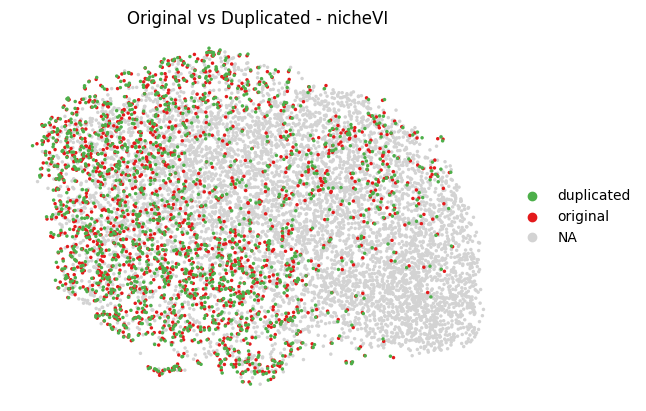

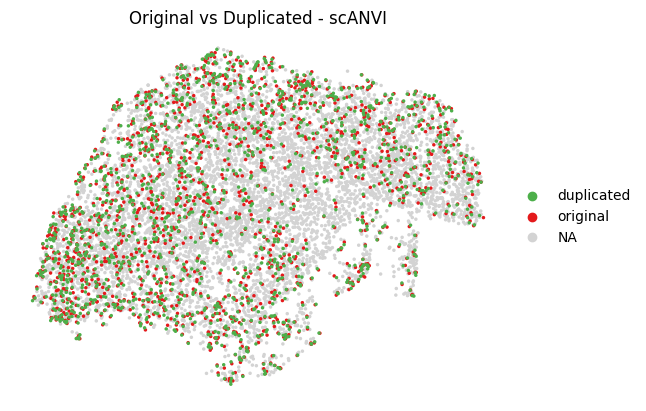

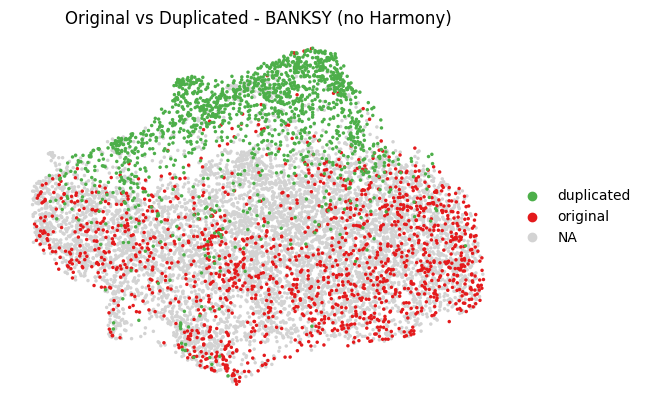

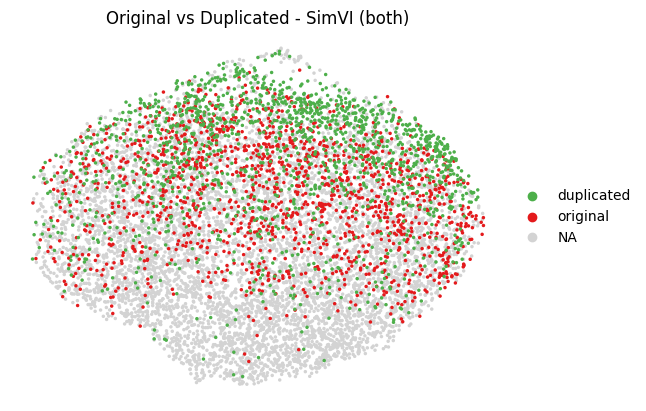

In [10]:
EMBEDDINGS = {
    "nicheVI": NICHEVI_KEY,
    "scANVI": "X_scanvi",
    "BANKSY (no Harmony)": "banksy_pc_20_lambda_0.2",
    "SimVI (both)": "simvi25_both_mae_50",
}

for name, key in EMBEDDINGS.items():
    if key not in adata_target.obsm:
        print(f"skipping {name} - {key} not in obsm")
        continue
    sc.pp.neighbors(adata_target, n_neighbors=20, use_rep=key)
    sc.tl.umap(adata_target, min_dist=0.3)
    sc.pl.umap(
        adata_target,
        color="replacement_status",
        title=f"Original vs Duplicated - {name}",
        palette=["#4daf4a", "#e41a1c"],
        groups=["original", "duplicated"],
        size=25,
        frameon=False,
        show=False,
    )
    slug = name.lower().replace(" ", "_").replace("(", "").replace(")", "")
    plt.savefig(f"{FIGURE_DIR}{run_tag}_umap_{slug}.png", bbox_inches="tight", dpi=300)
    plt.savefig(f"{FIGURE_DIR}{run_tag}_umap_{slug}.svg", bbox_inches="tight", dpi=300)
    plt.show()

## iLISI: do the duplicates mix with the genuine residents of the target niche?


In [13]:
from nichevi.spatial_analysis import _integration_lisi

adata_ud = adata_target[adata_target.obs["replacement_status"].isin(["untouched", "duplicated"])].copy()
print(adata_ud.obs["replacement_status"].value_counts())

for name, key in EMBEDDINGS.items():
    if key not in adata_ud.obsm:
        print(f"skipping {name} - {key} not in obsm")
        continue
    adata_ud.obs["iLISI_" + key] = _integration_lisi(
        adata_ud,
        embedding_key=key,
        label_key="replacement_status",
        n_neighbors=90,
        perplexity=30,
    )


replacement_status
untouched     6731
duplicated    1500
Name: count, dtype: int64

Computing iLISI for s10_scanvi_lr0.0005_poisson_X_nicheVI based on replacement_status
Number of batches: 2
Min 0.99999905 Max 1.9999998
Median iLISI: 0.26866555
Mean iLISI: 0.3749872
Computing iLISI for X_scanvi based on replacement_status
Number of batches: 2
Min 0.9999993 Max 2.0
Median iLISI: 0.34603572
Mean iLISI: 0.41091725
Computing iLISI for banksy_pc_20_lambda_0.2 based on replacement_status
Number of batches: 2
Min 0.9999988 Max 1.9999995
Median iLISI: 0.018277049
Mean iLISI: 0.14474261
Computing iLISI for simvi25_both_mae_50 based on replacement_status
Number of batches: 2
Min 0.99999905 Max 1.9999995
Median iLISI: 0.11009908
Mean iLISI: 0.24482954


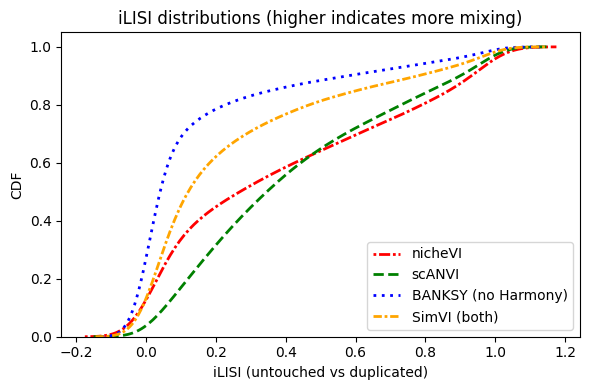

In [11]:
import seaborn as sns

styles = {
    "scANVI": {"color": "green", "linestyle": "--"},
    "BANKSY (no Harmony)": {"color": "blue", "linestyle": (0, (1, 2))},
    "nicheVI": {"color": "red", "linestyle": (0, (1, 1, 4, 1))},
    "SimVI (both)": {"color": "orange", "linestyle": (0, (3, 1, 1, 1))},
}

plt.figure(figsize=(6, 4))
for name, key in EMBEDDINGS.items():
    col = "iLISI_" + key
    if col not in adata_ud.obs:
        continue
    sns.kdeplot(
        adata_ud.obs[col].dropna(),
        label=name,
        color=styles[name]["color"],
        linestyle=styles[name]["linestyle"],
        linewidth=2,
        common_norm=True,
        cumulative=True,
    )

plt.xlabel("iLISI (untouched vs duplicated)")
plt.ylabel("CDF")
plt.title("iLISI distributions (higher indicates more mixing)")
plt.legend()
plt.tight_layout()
plt.savefig(f"{FIGURE_DIR}{run_tag}_ilisi_comparison.png", bbox_inches="tight", dpi=300)
plt.savefig(f"{FIGURE_DIR}{run_tag}_ilisi_comparison.svg", bbox_inches="tight", dpi=300)
plt.show()
